In [4]:
!pip install torch


In [6]:
import torch
print("PyTorch available:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU - will use CPU")

PyTorch available: 2.11.0+cpu
GPU available: False
No GPU - will use CPU


In [7]:
!pip install torch torchvision matplotlib scikit-learn pillow

   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.3 MB 479.2 kB/s eta 0:00:08
   ------------ --------------------------- 1.3/4.3 MB 1.2 MB/s eta 0:00:03
   ---------------------- ----------------- 2.4/4.3 MB 2.0 MB/s eta 0:00:01
   --------------------------- ------------ 2.9/4.3 MB 2.2 MB/s eta 0:00:01
   ----------------------------- ---------- 3.1/4.3 MB 2.2 MB/s eta 0:00:01
   ------------------------------------ --- 3.9/4.3 MB 2.2 MB/s eta 0:00:01
   ---------------------------------------  4.2/4.3 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 

In [8]:
import torch
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
import os

print("✅ PyTorch:", torch.__version__)
print("✅ Torchvision:", torchvision.__version__)
print("✅ All libraries imported successfully!")
print("\nDevice:", "GPU" if torch.cuda.is_available() else "CPU")

✅ PyTorch: 2.11.0+cpu
✅ Torchvision: 0.26.0+cpu
✅ All libraries imported successfully!

Device: CPU


In [10]:
import os

# Set dataset path
dataset_path = "casting_512x512"

# Check folders
folders = os.listdir(dataset_path)
print("Folders found:", folders)

# Count images in each folder
for folder in folders:
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        images = os.listdir(folder_path)
        print(f"\nFolder: {folder}")
        print(f"Total Images: {len(images)}")

Folders found: ['def_front', 'ok_front']

Folder: def_front
Total Images: 781

Folder: ok_front
Total Images: 519


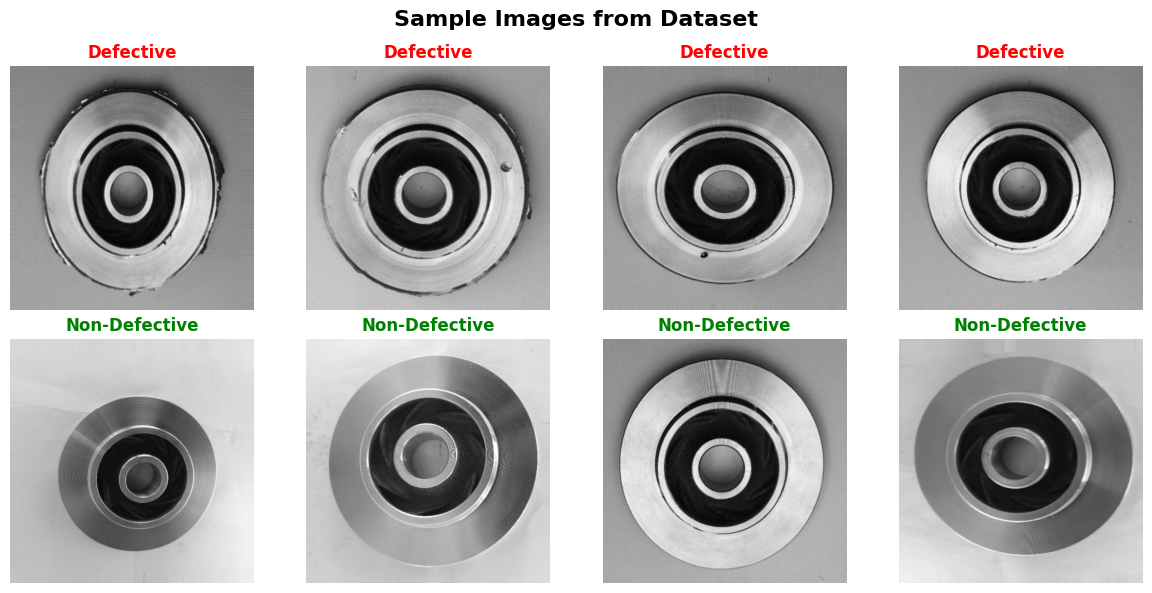

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Sample Images from Dataset", fontsize=16, fontweight='bold')

# Show defective images
def_path = "casting_512x512/def_front"
def_images = os.listdir(def_path)[:4]

for i, img_name in enumerate(def_images):
    img = Image.open(os.path.join(def_path, img_name))
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title("Defective", color='red', fontweight='bold')
    axes[0, i].axis('off')

# Show ok images
ok_path = "casting_512x512/ok_front"
ok_images = os.listdir(ok_path)[:4]

for i, img_name in enumerate(ok_images):
    img = Image.open(os.path.join(ok_path, img_name))
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title("Non-Defective", color='green', fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [12]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Step 1 - Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),      # Resize all images to 224x224
    transforms.ToTensor(),               # Convert image to tensor (numbers)
    transforms.Normalize(               # Normalize pixel values
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Step 2 - Load dataset
dataset = datasets.ImageFolder(
    root="casting_512x512",
    transform=transform
)

# Step 3 - Check classes
print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)
print("Total Images:", len(dataset))

Classes: ['def_front', 'ok_front']
Class mapping: {'def_front': 0, 'ok_front': 1}
Total Images: 1300


In [13]:
# Step 4 - Split dataset
train_size = int(0.8 * len(dataset))   # 80% for training
test_size = len(dataset) - train_size   # 20% for testing

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))

# Step 5 - Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("\nTraining Batches:", len(train_loader))
print("Testing Batches:", len(test_loader))

Training Images: 1040
Testing Images: 260

Training Batches: 33
Testing Batches: 9


In [14]:
import torch.nn as nn
from torchvision import models

# Step 6 - Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Step 7 - Modify last layer for our 2 classes
# ResNet18 originally classifies 1000 classes
# We only need 2 classes (Defective / Non-Defective)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

print("Model loaded successfully!")
print("Output classes:", 2)
print("\nFinal Layer:", model.fc)

C:\Users\MANJUNATH S V\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\MANJUNATH S V\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\MANJUNATH S V/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:19<00:00, 2.34MB/s]

Model loaded successfully!
Output classes: 2

Final Layer: Linear(in_features=512, out_features=2, bias=True)


In [15]:
import torch.optim as optim

# Step 8 - Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Step 9 - Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Loss Function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning Rate: 0.001")
print("Device:", device)

Loss Function: CrossEntropyLoss
Optimizer: Adam
Learning Rate: 0.001
Device: cpu


In [16]:
# Step 10 - Training function
def train_model(model, train_loader, criterion, optimizer, epochs=5):
    
    print("=" * 50)
    print("        TRAINING STARTED")
    print("=" * 50)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Calculate accuracy
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        
        print(f"Epoch [{epoch+1}/{epochs}]  Loss: {epoch_loss:.4f}  Accuracy: {epoch_acc:.2f}%")
    
    print("=" * 50)
    print("TRAINING COMPLETE!")
    print("=" * 50)

# Start training
train_model(model, train_loader, criterion, optimizer, epochs=5)

        TRAINING STARTED
Epoch [1/5]  Loss: 0.4239  Accuracy: 83.94%
Epoch [2/5]  Loss: 0.0808  Accuracy: 97.60%
Epoch [3/5]  Loss: 0.0624  Accuracy: 97.79%
Epoch [4/5]  Loss: 0.0939  Accuracy: 96.54%
Epoch [5/5]  Loss: 0.0319  Accuracy: 99.04%
TRAINING COMPLETE!


In [17]:
# Step 11 - Evaluate on test data
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100 * correct / total
    print("=" * 50)
    print(f"Test Accuracy: {accuracy:.2f}%")
    print(f"Correct: {correct}/{total}")
    print("=" * 50)
    
    return all_preds, all_labels

preds, labels = evaluate_model(model, test_loader)

Test Accuracy: 98.85%
Correct: 257/260


CLASSIFICATION REPORT
               precision    recall  f1-score   support

    Defective       0.99      0.99      0.99       160
Non-Defective       0.98      0.99      0.99       100

     accuracy                           0.99       260
    macro avg       0.99      0.99      0.99       260
 weighted avg       0.99      0.99      0.99       260



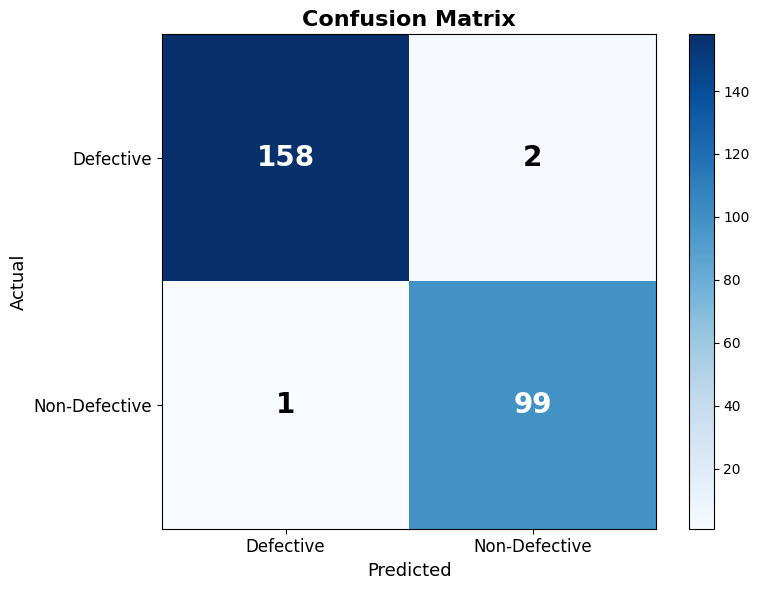


Confusion Matrix:
[[158   2]
 [  1  99]]


In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Classification Report
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(
    labels, preds,
    target_names=['Defective', 'Non-Defective']
))

# Confusion Matrix
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.colorbar()
plt.xticks([0, 1], ['Defective', 'Non-Defective'], fontsize=12)
plt.yticks([0, 1], ['Defective', 'Non-Defective'], fontsize=12)

# Add numbers inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i][j]),
                ha='center', va='center',
                fontsize=20, fontweight='bold',
                color='white' if cm[i][j] > cm.max()/2 else 'black')

plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(cm)

In [19]:
# Save the trained model
torch.save(model.state_dict(), 'defect_detection_model.pth')
print("✅ Model saved successfully!")
print("File: defect_detection_model.pth")

✅ Model saved successfully!
File: defect_detection_model.pth


In [20]:
!pip install gradio

   ---------------------------------------- 0.0/19.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.6 MB ? eta -:--:--
    --------------------------------------- 0.3/19.6 MB ? eta -:--:--
   - -------------------------------------- 0.8/19.6 MB 1.3 MB/s eta 0:00:15
   -- ------------------------------------- 1.0/19.6 MB 1.5 MB/s eta 0:00:13
   -- ------------------------------------- 1.3/19.6 MB 1.6 MB/s eta 0:00:12
   -- ------------------------------------- 1.3/19.6 MB 1.6 MB/s eta 0:00:12
   -- ------------------------------------- 1.3/19.6 MB 1.6 MB/s eta 0:00:12
   --- ------------------------------------ 1.6/19.6 MB 998.3 kB/s eta 0:00:19
   --- ------------------------------------ 1.6/19.6 MB 998.3 kB/s eta 0:00:19
   --- ------------------------------------ 1.8/19.6 MB 890.6 kB/s eta 0:00:20
   ---- ----------------------------------- 2.1/19.6 MB 917.5 kB/s eta 0:00:20
   ---- -----------